In [47]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import RandomOverSampler
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier

In [3]:
data = pd.read_csv('cdd.csv')

In [4]:
X = data.drop('Class', axis=1)
y = data['Class']


In [44]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("NaN values in y_train:", np.isnan(y_train).sum())
y_train = y_train.to_numpy().reshape(-1, 1)  # Convert Series to 2D array
imputer = SimpleImputer(strategy='most_frequent')
y_train = imputer.fit_transform(y_train).ravel()  # Impute and flatten back to 1D

# Initialize Random Forest model
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_classifier.fit(X_train, y_train)

# Predictions
y_pred = rf_classifier.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Random Forest Model Accuracy:", accuracy)




NaN values in y_train: 0
Random Forest Model Accuracy: 0.975


In [45]:
rf_classifier.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [48]:
models = {
    "Logistic Regression": LogisticRegression(solver='liblinear'),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(kernel='linear')
}

# Train and evaluate each model
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"{name} Accuracy: {accuracy:.4f}")

Logistic Regression Accuracy: 0.9250
Random Forest Accuracy: 0.9750
Decision Tree Accuracy: 0.9750
KNN Accuracy: 0.9250
SVM Accuracy: 0.9000


In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [7]:
random_forest_model = RandomForestClassifier(random_state=42)
random_forest_model.fit(X_train, y_train)
y_pred_rf = random_forest_model.predict(X_test)


In [8]:
print("Random Forest Model:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.2f}")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred_rf)}")
print(f"Classification Report:\n{classification_report(y_test, y_pred_rf)}")
print("-" * 50)

Random Forest Model:
Accuracy: 0.97
Confusion Matrix:
[[18  1]
 [ 0 21]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.95      0.97        19
           1       0.95      1.00      0.98        21

    accuracy                           0.97        40
   macro avg       0.98      0.97      0.97        40
weighted avg       0.98      0.97      0.97        40

--------------------------------------------------


In [9]:
logistic_regression_model = LogisticRegression(random_state=42, max_iter=1000)
logistic_regression_model.fit(X_train_scaled, y_train)
y_pred_lr = logistic_regression_model.predict(X_test_scaled)

In [10]:
print("Logistic Regression Model:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.2f}")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred_lr)}")
print(f"Classification Report:\n{classification_report(y_test, y_pred_lr)}")
print("-" * 50)


Logistic Regression Model:
Accuracy: 0.93
Confusion Matrix:
[[17  2]
 [ 1 20]]
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.89      0.92        19
           1       0.91      0.95      0.93        21

    accuracy                           0.93        40
   macro avg       0.93      0.92      0.92        40
weighted avg       0.93      0.93      0.92        40

--------------------------------------------------


In [11]:
svm_model = SVC(random_state=42)
svm_model.fit(X_train_scaled, y_train)
y_pred_svm = svm_model.predict(X_test_scaled)

In [12]:
print("Support Vector Machine (SVM) Model:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm):.2f}")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred_svm)}")
print(f"Classification Report:\n{classification_report(y_test, y_pred_svm)}")
print("-" * 50)

Support Vector Machine (SVM) Model:
Accuracy: 0.78
Confusion Matrix:
[[17  2]
 [ 7 14]]
Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.89      0.79        19
           1       0.88      0.67      0.76        21

    accuracy                           0.78        40
   macro avg       0.79      0.78      0.77        40
weighted avg       0.80      0.78      0.77        40

--------------------------------------------------


<ipython-input-39-8450e7e1ecf1>:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_resampled["Class"], palette="muted")


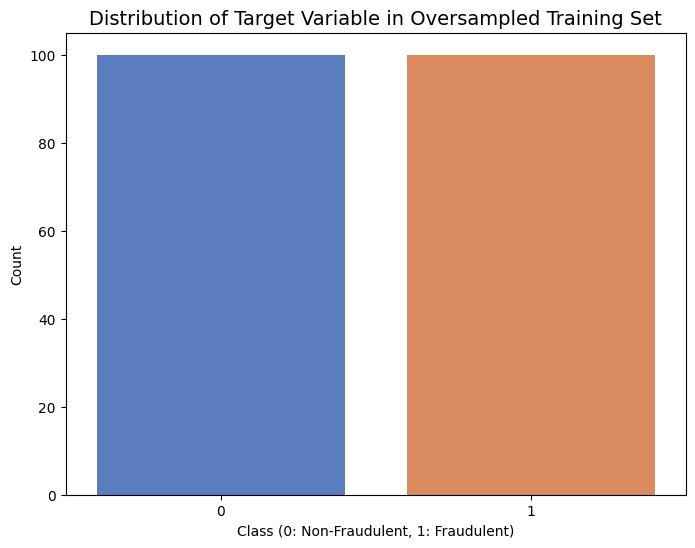

In [39]:

# Define features and target variable
X = data.drop(columns=['Class'])  # Features
y = data['Class']  # Target variable

# Apply Random Oversampling
ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X, y)

# Convert back to DataFrame for visualization
df_resampled = pd.DataFrame(X_resampled, columns=X.columns)
df_resampled['Class'] = y_resampled

# Plot the distribution
plt.figure(figsize=(8, 6))
sns.countplot(x=df_resampled["Class"], palette="muted")
plt.title("Distribution of Target Variable in Oversampled Training Set", fontsize=14)
plt.xlabel("Class (0: Non-Fraudulent, 1: Fraudulent)")
plt.ylabel("Count")
plt.xticks([0, 1], ["0", "1"])

# Show plot
plt.show()

In [13]:
knn_model = KNeighborsClassifier()
knn_model.fit(X_train_scaled, y_train)
y_pred_knn = knn_model.predict(X_test_scaled)

In [14]:
print("K-Nearest Neighbors (KNN) Model:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn):.2f}")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred_knn)}")
print(f"Classification Report:\n{classification_report(y_test, y_pred_knn)}")
print("-" * 50)

K-Nearest Neighbors (KNN) Model:
Accuracy: 0.75
Confusion Matrix:
[[13  6]
 [ 4 17]]
Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.68      0.72        19
           1       0.74      0.81      0.77        21

    accuracy                           0.75        40
   macro avg       0.75      0.75      0.75        40
weighted avg       0.75      0.75      0.75        40

--------------------------------------------------


<ipython-input-34-c1b68338a2a5>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y=feature, data=data, palette="coolwarm")
<ipython-input-34-c1b68338a2a5>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y=feature, data=data, palette="coolwarm")
<ipython-input-34-c1b68338a2a5>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y=feature, data=data, palette="coolwarm")
<ipython-input-34-c1b68338a2a5>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assig

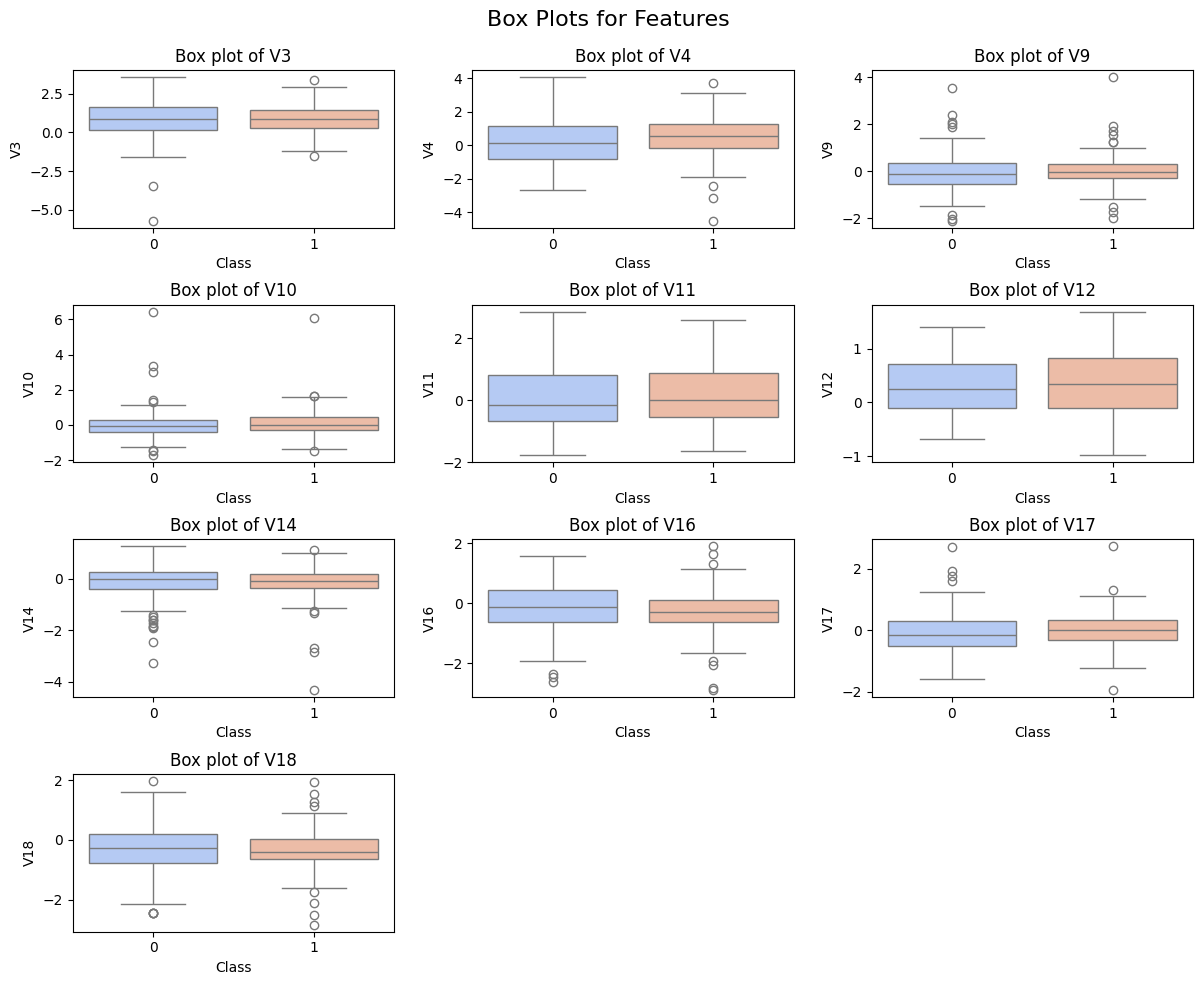

In [34]:
features = ['V3', 'V4', 'V9', 'V10', 'V11', 'V12', 'V14', 'V16', 'V17', 'V18']


plt.figure(figsize=(12, 10))
for i, feature in enumerate(features):
    plt.subplot(4, 3, i + 1)
    sns.boxplot(x='Class', y=feature, data=data, palette="coolwarm")
    plt.title(f'Box plot of {feature}')

plt.tight_layout()
plt.suptitle("Box Plots for Features", fontsize=16)
plt.subplots_adjust(top=0.92)
plt.show()

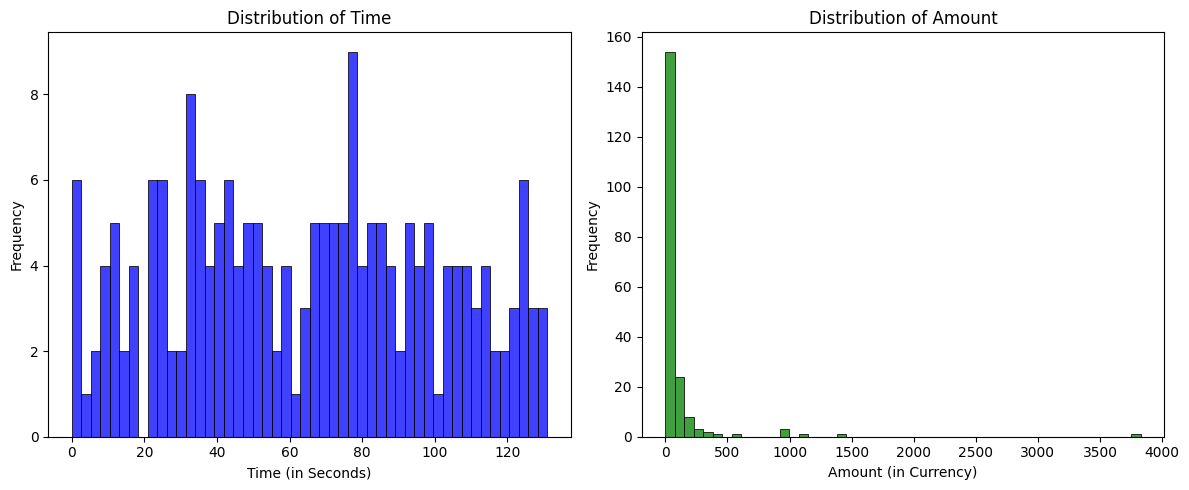

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))


sns.histplot(data['Time'], bins=50, kde=False, color="blue", ax=axes[0])
axes[0].set_title("Distribution of Time")
axes[0].set_xlabel("Time (in Seconds)")
axes[0].set_ylabel("Frequency")


sns.histplot(data['Amount'], bins=50, kde=False, color="green", ax=axes[1])
axes[1].set_title("Distribution of Amount")
axes[1].set_xlabel("Amount (in Currency)")
axes[1].set_ylabel("Frequency")


plt.tight_layout()
plt.show()


In [15]:
print("Please enter values for the features to predict the class:")
feature_names = X.columns.tolist()


Please enter values for the features to predict the class:


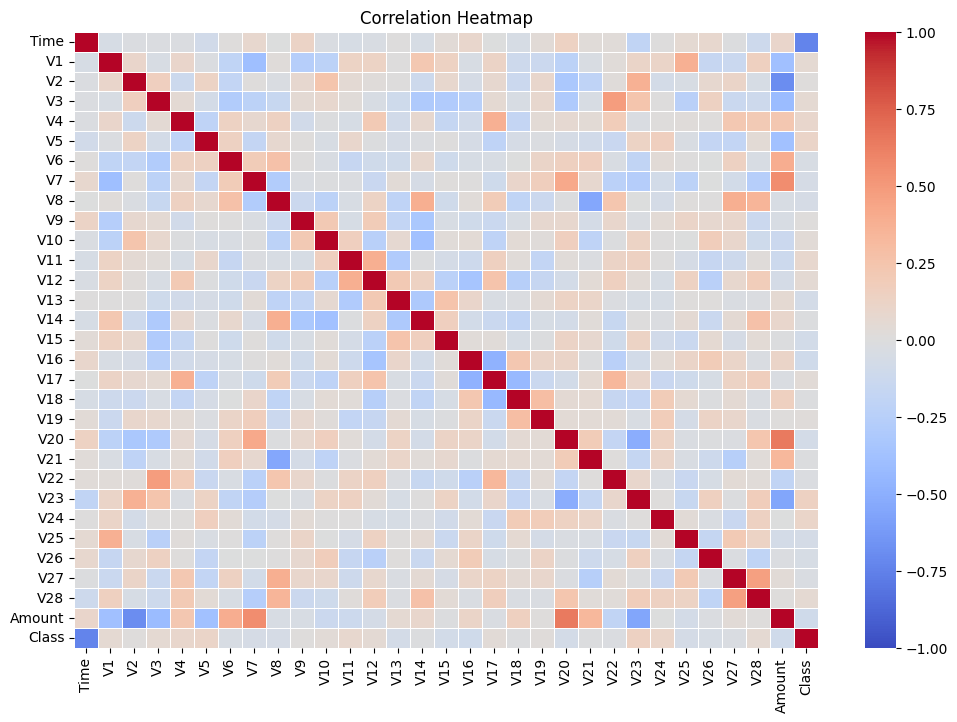

In [29]:
corr_matrix = data.corr()


plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=False, fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title("Correlation Heatmap")
plt.show()

In [31]:
user_input = []
for feature in feature_names:
    value = float(input(f"Enter value for {feature}: "))
    user_input.append(value)

Enter value for Time: 50000
Enter value for V1: 1.2
Enter value for V2: 32
Enter value for V3: 3.3
Enter value for V4: 4.5
Enter value for V5: 4.2
Enter value for V6: .3
Enter value for V7: 3.2
Enter value for V8: 32.2
Enter value for V9: 4.3
Enter value for V10: 4.
Enter value for V11: 4.0
Enter value for V12: 4.6
Enter value for V13: 4.5
Enter value for V14: 4.6
Enter value for V15: 5.0
Enter value for V16: 0.10
Enter value for V17: 5.15
Enter value for V18: 5.90
Enter value for V19: 6.90
Enter value for V20: 5.9002
Enter value for V21: 8.908
Enter value for V22: 9.024
Enter value for V23: -343.3
Enter value for V24: -7.90
Enter value for V25: -9.89
Enter value for V26: 4.564
Enter value for V27: -9.89
Enter value for V28: 4.43
Enter value for Amount: 4000


In [32]:
import numpy as np

print("\nPredictions for user input:")
user_input_array = np.array(user_input).reshape(1, -1)  # Convert to 2D array

print(f"Random Forest Prediction: {random_forest_model.predict(user_input_array)[0]}")
print(f"Logistic Regression Prediction: {logistic_regression_model.predict(user_input_array)[0]}")
print(f"SVM Prediction: {svm_model.predict(user_input_array)[0]}")
print(f"KNN Prediction: {knn_model.predict(user_input_array)[0]}")



Predictions for user input:
Random Forest Prediction: 0
Logistic Regression Prediction: 0
SVM Prediction: 0
KNN Prediction: 0


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
